# Mall Customer Analysis System
Customer segmentation using K-Means clustering on spending behaviour and demographics.

## 1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
print("Libraries imported successfully")

Libraries imported successfully


## 2. Load the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()   # choose Mall_Customers.csv

df = pd.read_csv("Mall_Customers.csv")
print("Dataset loaded successfully")
df.head()

Saving Mall_Customers.csv to Mall_Customers.csv
Dataset loaded successfully


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploratory Data Analysis (EDA)

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset Shape: (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Missing values and duplicate records

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0
Duplicate rows: 0


### Numerical and categorical columns

In [ ]:
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical columns: ['Gender']


### Distribution of numerical features

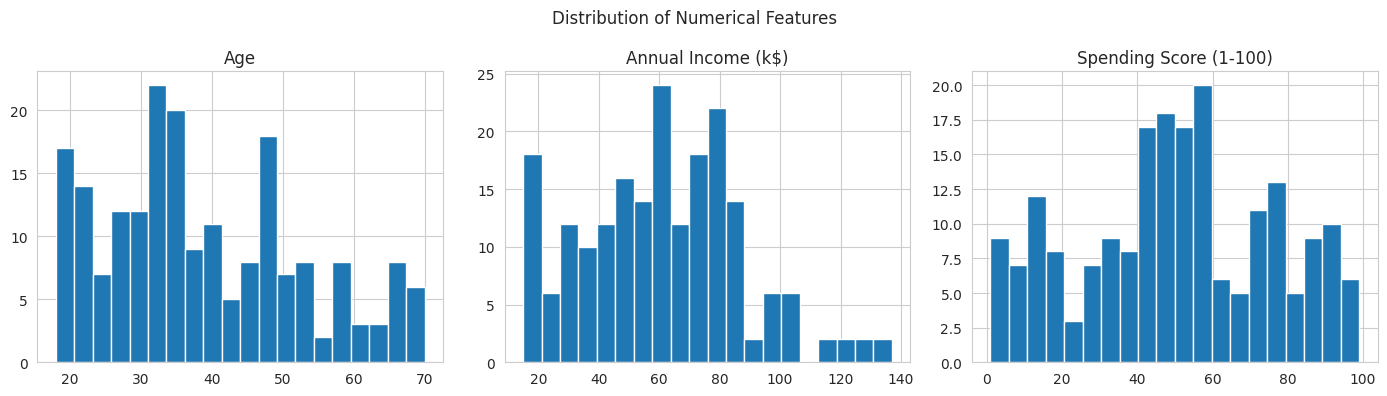

In [ ]:
df[num_cols].hist(figsize=(14, 4), bins=20, layout=(1, 3))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

### Boxplot

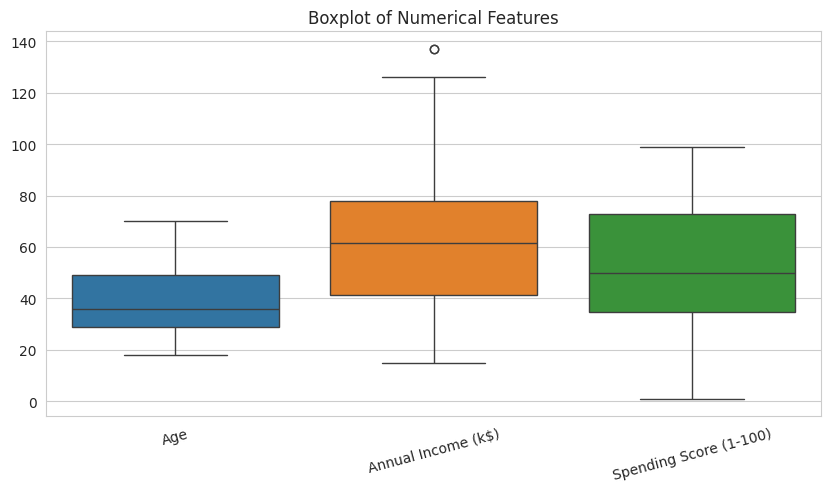

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=15)
plt.show()

### Gender distribution

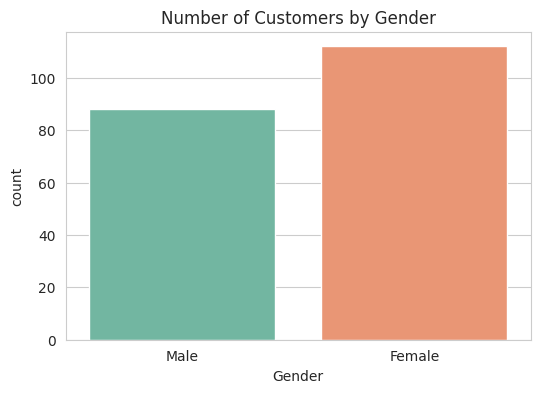

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Gender", hue="Gender", palette="Set2", legend=False)
plt.title("Number of Customers by Gender")
plt.show()

### Correlation heatmap

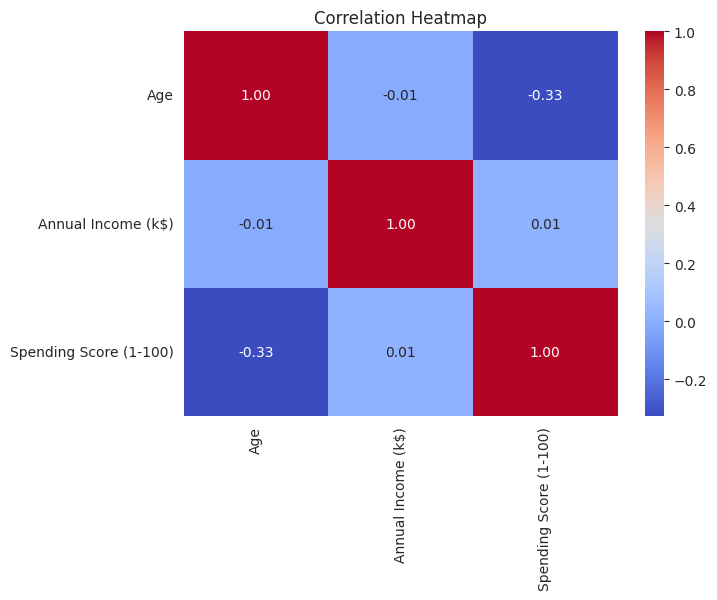

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Income vs Spending Score (before clustering)

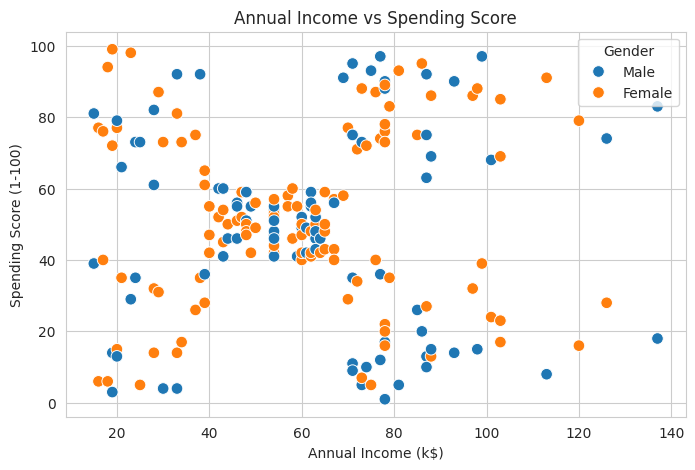

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Gender", s=70)
plt.title("Annual Income vs Spending Score")
plt.show()

### Age vs Spending Score

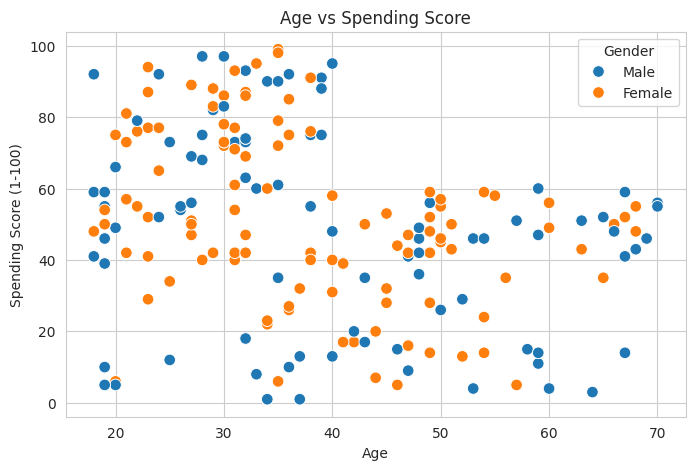

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Spending Score (1-100)", hue="Gender", s=70)
plt.title("Age vs Spending Score")
plt.show()

## 4. Preprocessing: feature selection and standardization

In [ ]:
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[features]

print("Feature matrix shape:", X.shape)
print("Selected features:", features)

Feature matrix shape: (200, 3)
Selected features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardized data (first 5 rows):")
display(pd.DataFrame(X_scaled, columns=features).head())

Standardized data (first 5 rows):


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## 5. Find the optimal number of clusters

K = 2, WCSS = 389.39, Silhouette = 0.335
K = 3, WCSS = 295.21, Silhouette = 0.358
K = 4, WCSS = 205.23, Silhouette = 0.404
K = 5, WCSS = 168.25, Silhouette = 0.417
K = 6, WCSS = 133.87, Silhouette = 0.428
K = 7, WCSS = 117.01, Silhouette = 0.417
K = 8, WCSS = 103.87, Silhouette = 0.408
K = 9, WCSS = 93.09, Silhouette = 0.418
K = 10, WCSS = 82.39, Silhouette = 0.407


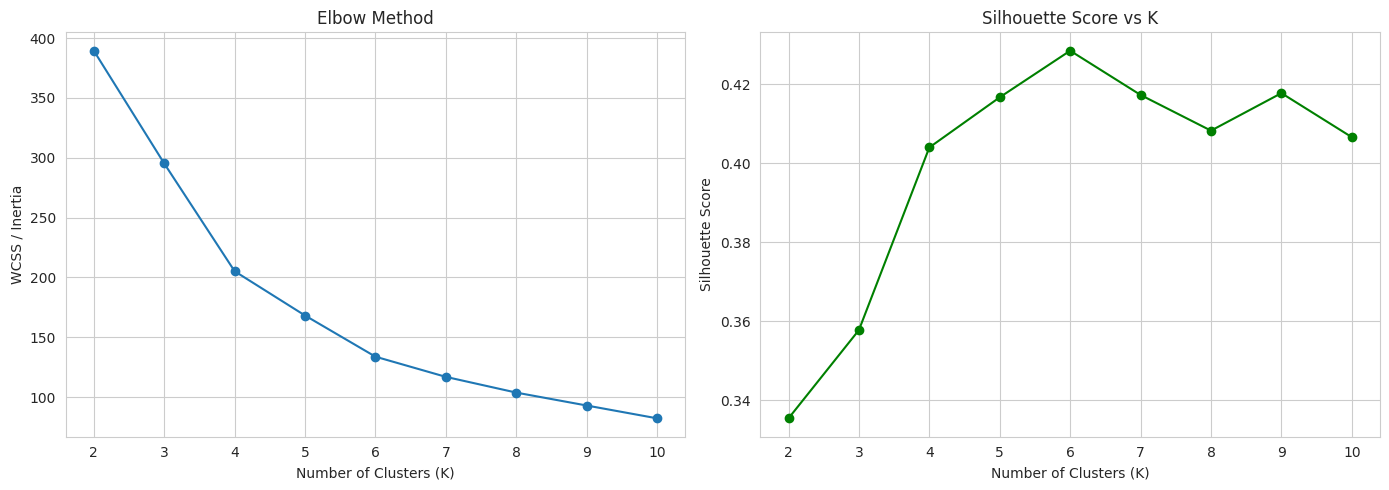

In [ ]:
wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"K = {k}, WCSS = {km.inertia_:.2f}, Silhouette = {sil_scores[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(list(k_range), wcss, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("WCSS / Inertia")
ax[0].set_xticks(list(k_range))

ax[1].plot(list(k_range), sil_scores, marker="o", color="green")
ax[1].set_title("Silhouette Score vs K")
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

**Choosing K:** the elbow flattens around K = 5, and silhouette scores for K = 5 to 10 are close together (about 0.41 to 0.43), so the score alone does not single out one value. K = 5 is chosen because it sits at the elbow and gives five clear, interpretable customer segments.

## 6. Apply K-Means clustering

In [ ]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Model trained successfully!")
print("Silhouette Score:", round(silhouette_score(X_scaled, df["Cluster"]), 3))
print("\nCustomers per cluster:")
print(df["Cluster"].value_counts().sort_index())

Model trained successfully!
Silhouette Score: 0.417

Customers per cluster:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


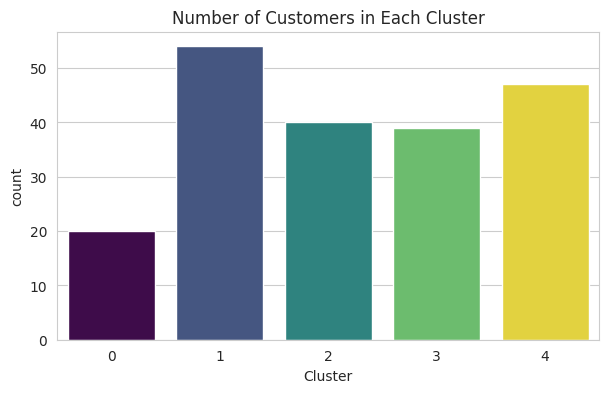

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Cluster", hue="Cluster", palette="viridis", legend=False)
plt.title("Number of Customers in Each Cluster")
plt.show()

## 7. Visualize the clusters

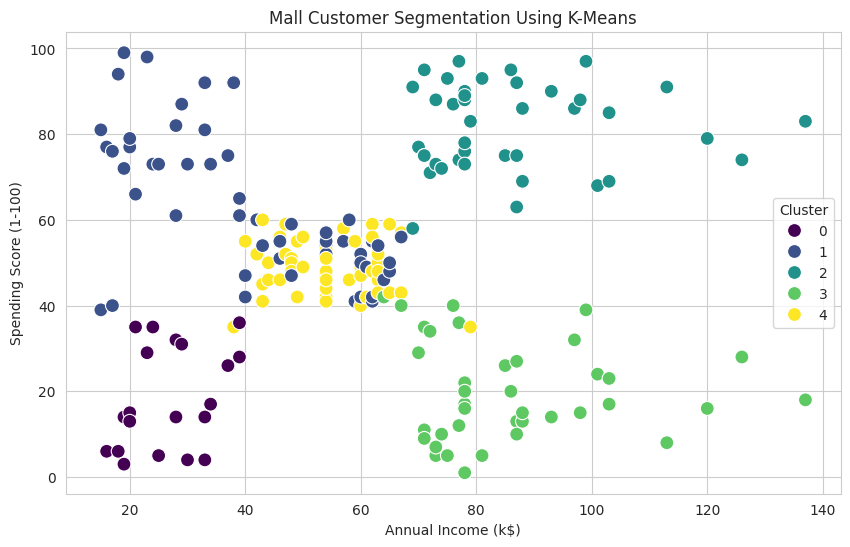

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Cluster", palette="viridis", s=100)
plt.title("Mall Customer Segmentation Using K-Means")
plt.legend(title="Cluster")
plt.show()

### PCA view (PC1 vs PC2)

Explained variance ratio: [44.27 33.31]
Total variance in 2 PCs: 77.57 %


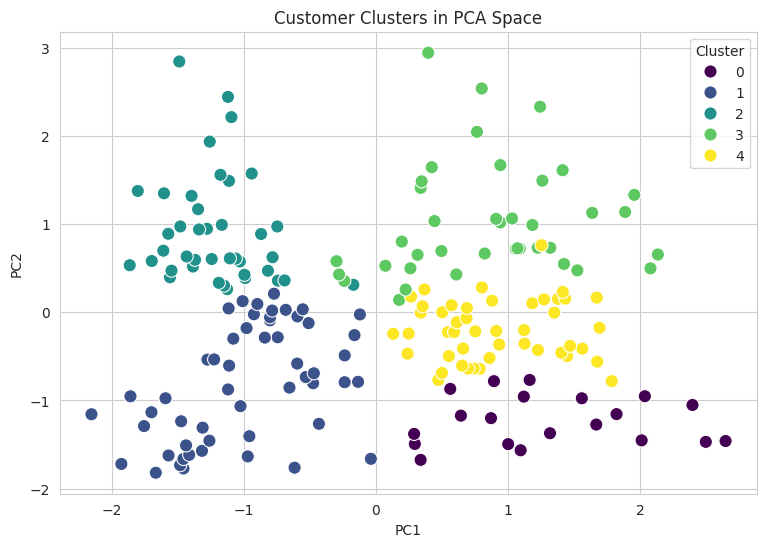

In [ ]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

print("Explained variance ratio:", (pca.explained_variance_ratio_ * 100).round(2))
print("Total variance in 2 PCs:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

plt.figure(figsize=(9, 6))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=df["Cluster"], palette="viridis", s=90)
plt.title("Customer Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

### 3D view

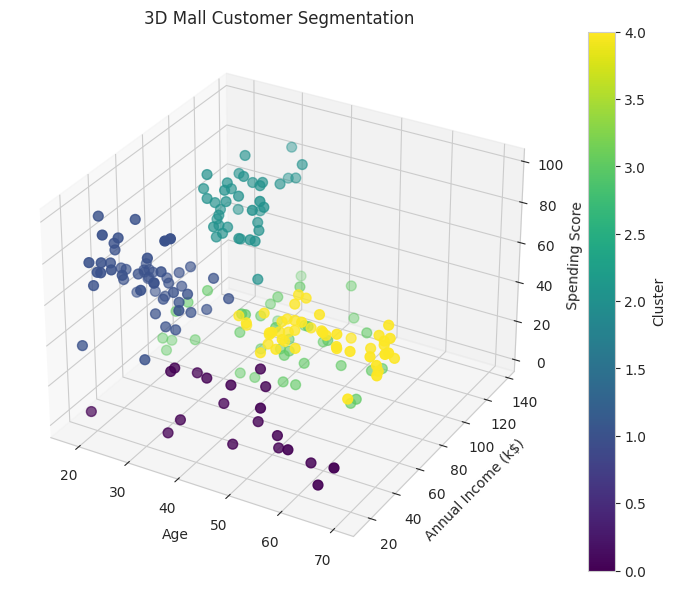

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(df["Age"], df["Annual Income (k$)"], df["Spending Score (1-100)"],
                c=df["Cluster"], cmap="viridis", s=50)
ax.set_title("3D Mall Customer Segmentation")
ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score")
plt.colorbar(sc, label="Cluster")
plt.show()

## 8. Cluster profiling

In [ ]:
segment_summary = df.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
).round(2)

display(segment_summary)

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,20,46.25,26.75,18.35
1,54,25.19,41.09,62.24
2,40,32.88,86.10,81.53
3,39,39.87,86.10,19.36
4,47,55.64,54.38,48.85


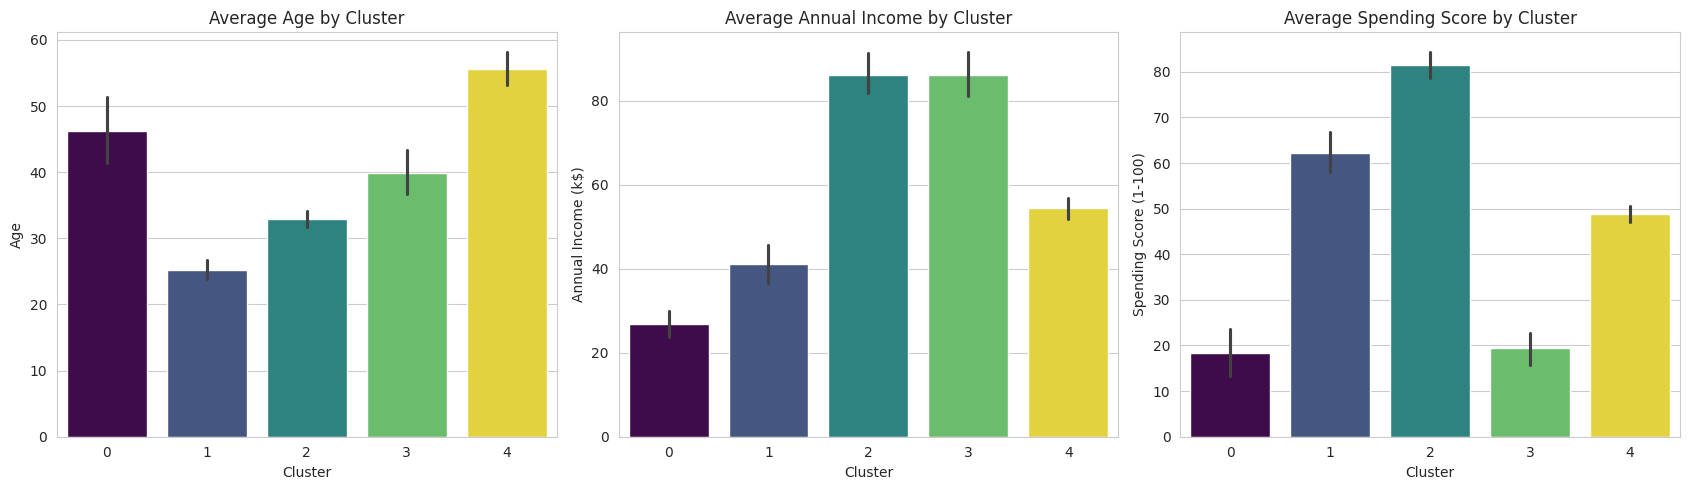

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.barplot(data=df, x="Cluster", y="Age", hue="Cluster", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Average Age by Cluster")

sns.barplot(data=df, x="Cluster", y="Annual Income (k$)", hue="Cluster", palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Average Annual Income by Cluster")

sns.barplot(data=df, x="Cluster", y="Spending Score (1-100)", hue="Cluster", palette="viridis", legend=False, ax=axes[2])
axes[2].set_title("Average Spending Score by Cluster")

plt.tight_layout()
plt.show()

### Gender distribution inside each cluster (%)

In [ ]:
gender_distribution = pd.crosstab(df["Cluster"], df["Gender"], normalize="index").mul(100).round(2)
display(gender_distribution)

Gender,Female,Male
Cluster,,
0,60.00,40.00
1,59.26,40.74
2,55.00,45.00
3,48.72,51.28
4,57.45,42.55


### Segment names (rule-based on cluster averages)

In [ ]:
def level(value, low, high):
    return "Low" if value < low else ("High" if value >= high else "Medium")

names = {}
for c, row in segment_summary.iterrows():
    inc = level(row["Average_Income"], 45, 70)
    spd = level(row["Average_Spending"], 40, 60)
    names[c] = f"{inc} income, {spd} spending"

df["Segment"] = df["Cluster"].map(names)

summary_named = segment_summary.copy()
summary_named["Segment"] = summary_named.index.map(names)
display(summary_named)

,Customer_Count,Average_Age,Average_Income,Average_Spending,Segment
Cluster,,,,,
0,20,46.25,26.75,18.35,"Low income, Low spending"
1,54,25.19,41.09,62.24,"Low income, High spending"
2,40,32.88,86.10,81.53,"High income, High spending"
3,39,39.87,86.10,19.36,"High income, Low spending"
4,47,55.64,54.38,48.85,"Medium income, Medium spending"


## 9. Save the model and export results

In [ ]:
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved successfully.")

df.to_csv("clustered_mall_customers.csv", index=False)
summary_named.to_csv("customer_segment_summary.csv")
print("Customer segmentation results exported successfully.")

Model and scaler saved successfully.
Customer segmentation results exported successfully.


In [ ]:
from google.colab import files
for f in ["kmeans_model.pkl", "scaler.pkl",
          "clustered_mall_customers.csv", "customer_segment_summary.csv"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Test the saved model on a new customer

In [ ]:
new_customer = pd.DataFrame([[30, 80, 75]], columns=features)   # Age, Income (k$), Spending Score
pred = kmeans.predict(scaler.transform(new_customer))[0]
print("Predicted cluster:", pred, "->", names[pred])

Predicted cluster: 2 -> High income, High spending
